# Universal Graph VAE Evaluation Notebook

This notebook provides a **standardised evaluation pipeline** for any Graph VAE architecture
registered in the model registry.

**Sections:**
1. Setup & Model Loading
2. Training History Analysis
3. VUN (Validity, Uniqueness, Novelty)
4. SA-Score & QED Analysis
5. Property Distribution Comparison
6. Latent Space Visualisation (t-SNE)
7. Generated Molecule Gallery

## 0. Configuration

Change these variables to evaluate a different architecture or weights.

In [14]:
ARCH_NAME       = "gin_vae"  
WEIGHTS_PATH    = "../../outputs/gin_vae/best_model.pth" 
HISTORY_PATH    = "../../outputs/gin_vae/history.json"
TRAIN_DATA_PATH = "../../data/subset/train.pt"
VAL_DATA_PATH   = "../../data/subset/val.pt"
TEST_DATA_PATH  = "../../data/subset/test.pt"

NUM_EVAL_SAMPLES = 1000  
MAX_TSNE_POINTS  = 3000  
BATCH_SIZE       = 128

HIDDEN_DIM  = 256
LATENT_DIM  = 256
MAX_NODES   = 37
USE_MULTI_BOND = True
USE_ONEHOT_ONLY = True
NUM_ENCODER_LAYERS = 4
DROPOUT = 0.1

## 1. Setup & Model Loading

In [15]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from rdkit import Chem

from src.config import TrainConfig, get_device, NUM_ATOM_TYPES
from src.model_registry import create_model
from src.evaluate_universal import UniversalEvaluator
import src.models 

device = get_device()
print(f"Device: {device}")

Device: mps


In [16]:
config = TrainConfig(
    arch=ARCH_NAME,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    max_nodes=MAX_NODES,
    use_multi_bond=USE_MULTI_BOND,
    use_onehot_only=USE_ONEHOT_ONLY,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    dropout=DROPOUT,
)

model = create_model(ARCH_NAME, config).to(device)

weights_abs = os.path.join(os.getcwd(), WEIGHTS_PATH)
if os.path.exists(weights_abs):
    model.load_state_dict(torch.load(weights_abs, map_location=device, weights_only=True))
    print(f"Loaded weights from {WEIGHTS_PATH}")
else:
    print(f"Weights not found at {weights_abs}")
  

model.eval()
print(f"Architecture: {ARCH_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Multi-bond: {model.is_multi_bond}")

Loaded weights from ../../outputs/gin_vae/best_model.pth
Architecture: gin_vae
Parameters: 1,817,976
Multi-bond: True


In [17]:
print("Loading datasets...")

train_data_abs = os.path.join(os.getcwd(), TRAIN_DATA_PATH)
val_data_abs = os.path.join(os.getcwd(), VAL_DATA_PATH)
test_data_abs = os.path.join(os.getcwd(), TEST_DATA_PATH)

train_dataset = torch.load(train_data_abs, weights_only=False)
val_dataset = torch.load(val_data_abs, weights_only=False)
test_dataset = torch.load(test_data_abs, weights_only=False)

train_dataset = [g for g in train_dataset if g.num_nodes <= MAX_NODES]
val_dataset = [g for g in val_dataset if g.num_nodes <= MAX_NODES]
test_dataset = [g for g in test_dataset if g.num_nodes <= MAX_NODES]

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_smiles = []
for g in train_dataset:
    if hasattr(g, 'smiles'):
        train_smiles.append(g.smiles)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading datasets...
Train: 15888, Val: 1986, Test: 1986


## 2. Training History Analysis

In [18]:
history_abs = os.path.join(os.getcwd(), HISTORY_PATH)
if os.path.exists(history_abs):
    UniversalEvaluator.plot_training_history(history_abs)
else:
    print(f"History not found at {history_abs} — skipping training curve plots.")

History not found at /Users/kornelorawczak/Documents/git_repos/Graph-Latent-Space/graphVAE/notebooks/../../outputs/gin_vae/history.json — skipping training curve plots.


## 3. VUN Analysis (Validity, Uniqueness, Novelty)

In [19]:
evaluator = UniversalEvaluator(model, device, train_smiles_list=train_smiles)
validity, uniqueness, novelty, valid_mols, valid_smiles = evaluator.evaluate_vun(
    num_samples=NUM_EVAL_SAMPLES
)

Sampling 1000 molecules from latent space...


Decoding:   0%|          | 0/1000 [00:00<?, ?it/s]

Decoding:  23%|██▎       | 228/1000 [00:00<00:01, 447.08it/s][23:09:13] Explicit valence for atom # 12 F, 2, is greater than permitted
[23:09:13] Explicit valence for atom # 1 O, 3, is greater than permitted
Decoding:  40%|████      | 402/1000 [00:01<00:01, 532.51it/s][23:09:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:09:14] Explicit valence for atom # 2 F, 2, is greater than permitted
Decoding:  74%|███████▎  | 736/1000 [00:01<00:00, 638.53it/s][23:09:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:09:14] Explicit valence for atom # 4 O, 3, is greater than permitted
Decoding:  94%|█████████▎| 935/1000 [00:01<00:00, 627.17it/s][23:09:14] Explicit valence for atom # 8 F, 2, is greater than permitted
[23:09:14] Explicit valence for atom # 12 F, 2, is greater than permitted
[23:09:15] Explicit valence for atom # 2 O, 3, is greater than permitted
Decoding: 100%|██████████| 1000/1000 [00:02<00:00, 491.80it/s]


╔══════════════════════════════════════╗
║         VUN Analysis Results         ║
╠══════════════════════════════════════╣
║  Validity:    98.40% (  984/1000 ) ║
║  Uniqueness:  41.67% (  410/984  ) ║
║  Novelty:    100.00% (  410/410  ) ║
╚══════════════════════════════════════╝


## 4. SA-Score & QED Analysis

In [20]:
gen_props = evaluator.compute_properties(valid_mols)
print(f"\nGenerated molecules with properties: {len(gen_props)}")
gen_props.describe()

Computing properties: 100%|██████████| 984/984 [00:00<00:00, 1151.31it/s]



Generated molecules with properties: 984


,molWt,HeavyAtomCount,cLogP,TPSA,HBD,HBA,NumRotatableBonds,RingCount,AromaticRingCount,FractionCSP3,QED,SA_score
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.0,984.0,984.000000,984.000000
mean,282.163366,19.830285,6.987319,11.252104,0.418699,0.852642,16.542683,0.004065,0.0,1.0,0.280355,1.546685
std,62.391907,4.440251,1.955444,12.322943,0.629470,0.852041,4.483292,0.063660,0.0,0.0,0.104699,0.442767
min,142.286000,10.000000,1.020700,0.000000,0.000000,0.000000,6.000000,0.000000,0.0,1.0,0.084646,1.058867
25%,228.420000,16.000000,5.695350,0.000000,0.000000,0.000000,13.000000,0.000000,0.0,1.0,0.195680,1.083382
50%,286.008000,20.000000,7.141250,9.230000,0.000000,1.000000,17.000000,0.000000,0.0,1.0,0.252005,1.564711
75%,338.664000,24.000000,8.438100,20.230000,1.000000,1.000000,20.000000,0.000000,0.0,1.0,0.364327,1.742335
max,412.743000,29.000000,11.558900,58.920000,3.000000,5.000000,26.000000,1.000000,0.0,1.0,0.607901,3.629270


SA-scores (generated): 100%|██████████| 984/984 [00:00<00:00, 16563.97it/s]


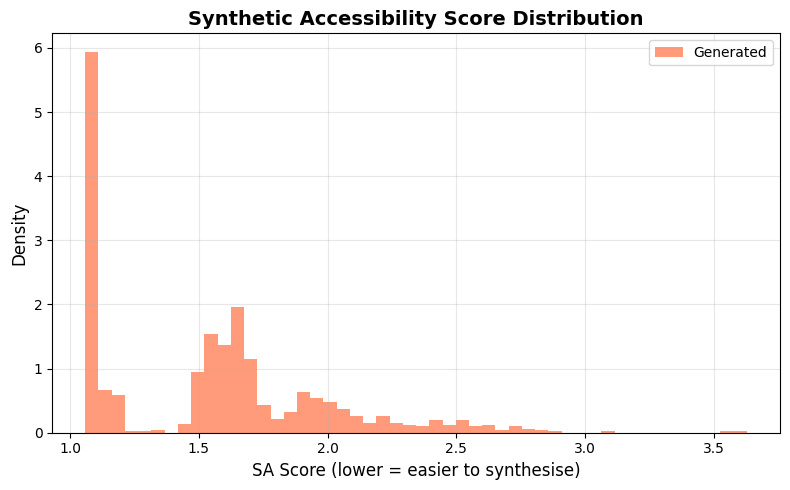

Generated SA-score:  mean=1.55  std=0.44


In [21]:
evaluator.plot_sa_scores(valid_mols)

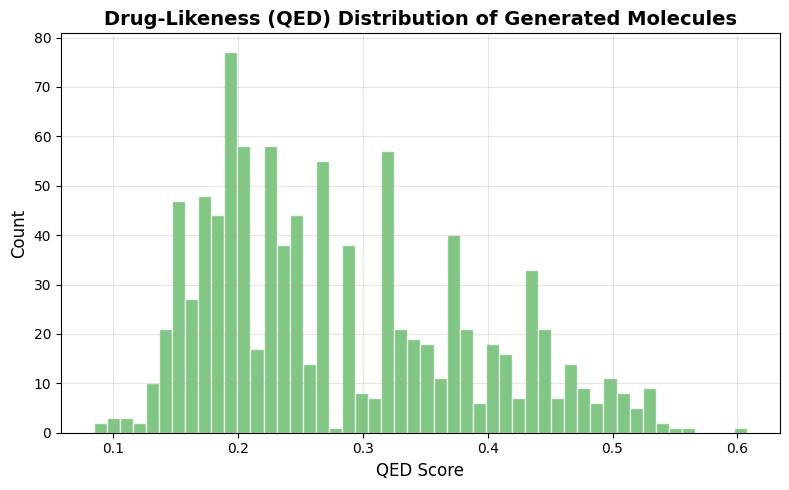

QED: mean=0.280, std=0.105


In [22]:
if 'QED' in gen_props.columns:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.hist(gen_props['QED'].dropna(), bins=50, alpha=0.7, color='#4CAF50', edgecolor='white')
    ax.set_xlabel('QED Score', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Drug-Likeness (QED) Distribution of Generated Molecules',
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"QED: mean={gen_props['QED'].mean():.3f}, std={gen_props['QED'].std():.3f}")

## 5. Property Distribution Comparison

Comparing generated molecule properties against the training data.

Computing properties for training molecules (sample)...


Computing properties: 100%|██████████| 2000/2000 [00:02<00:00, 871.58it/s]


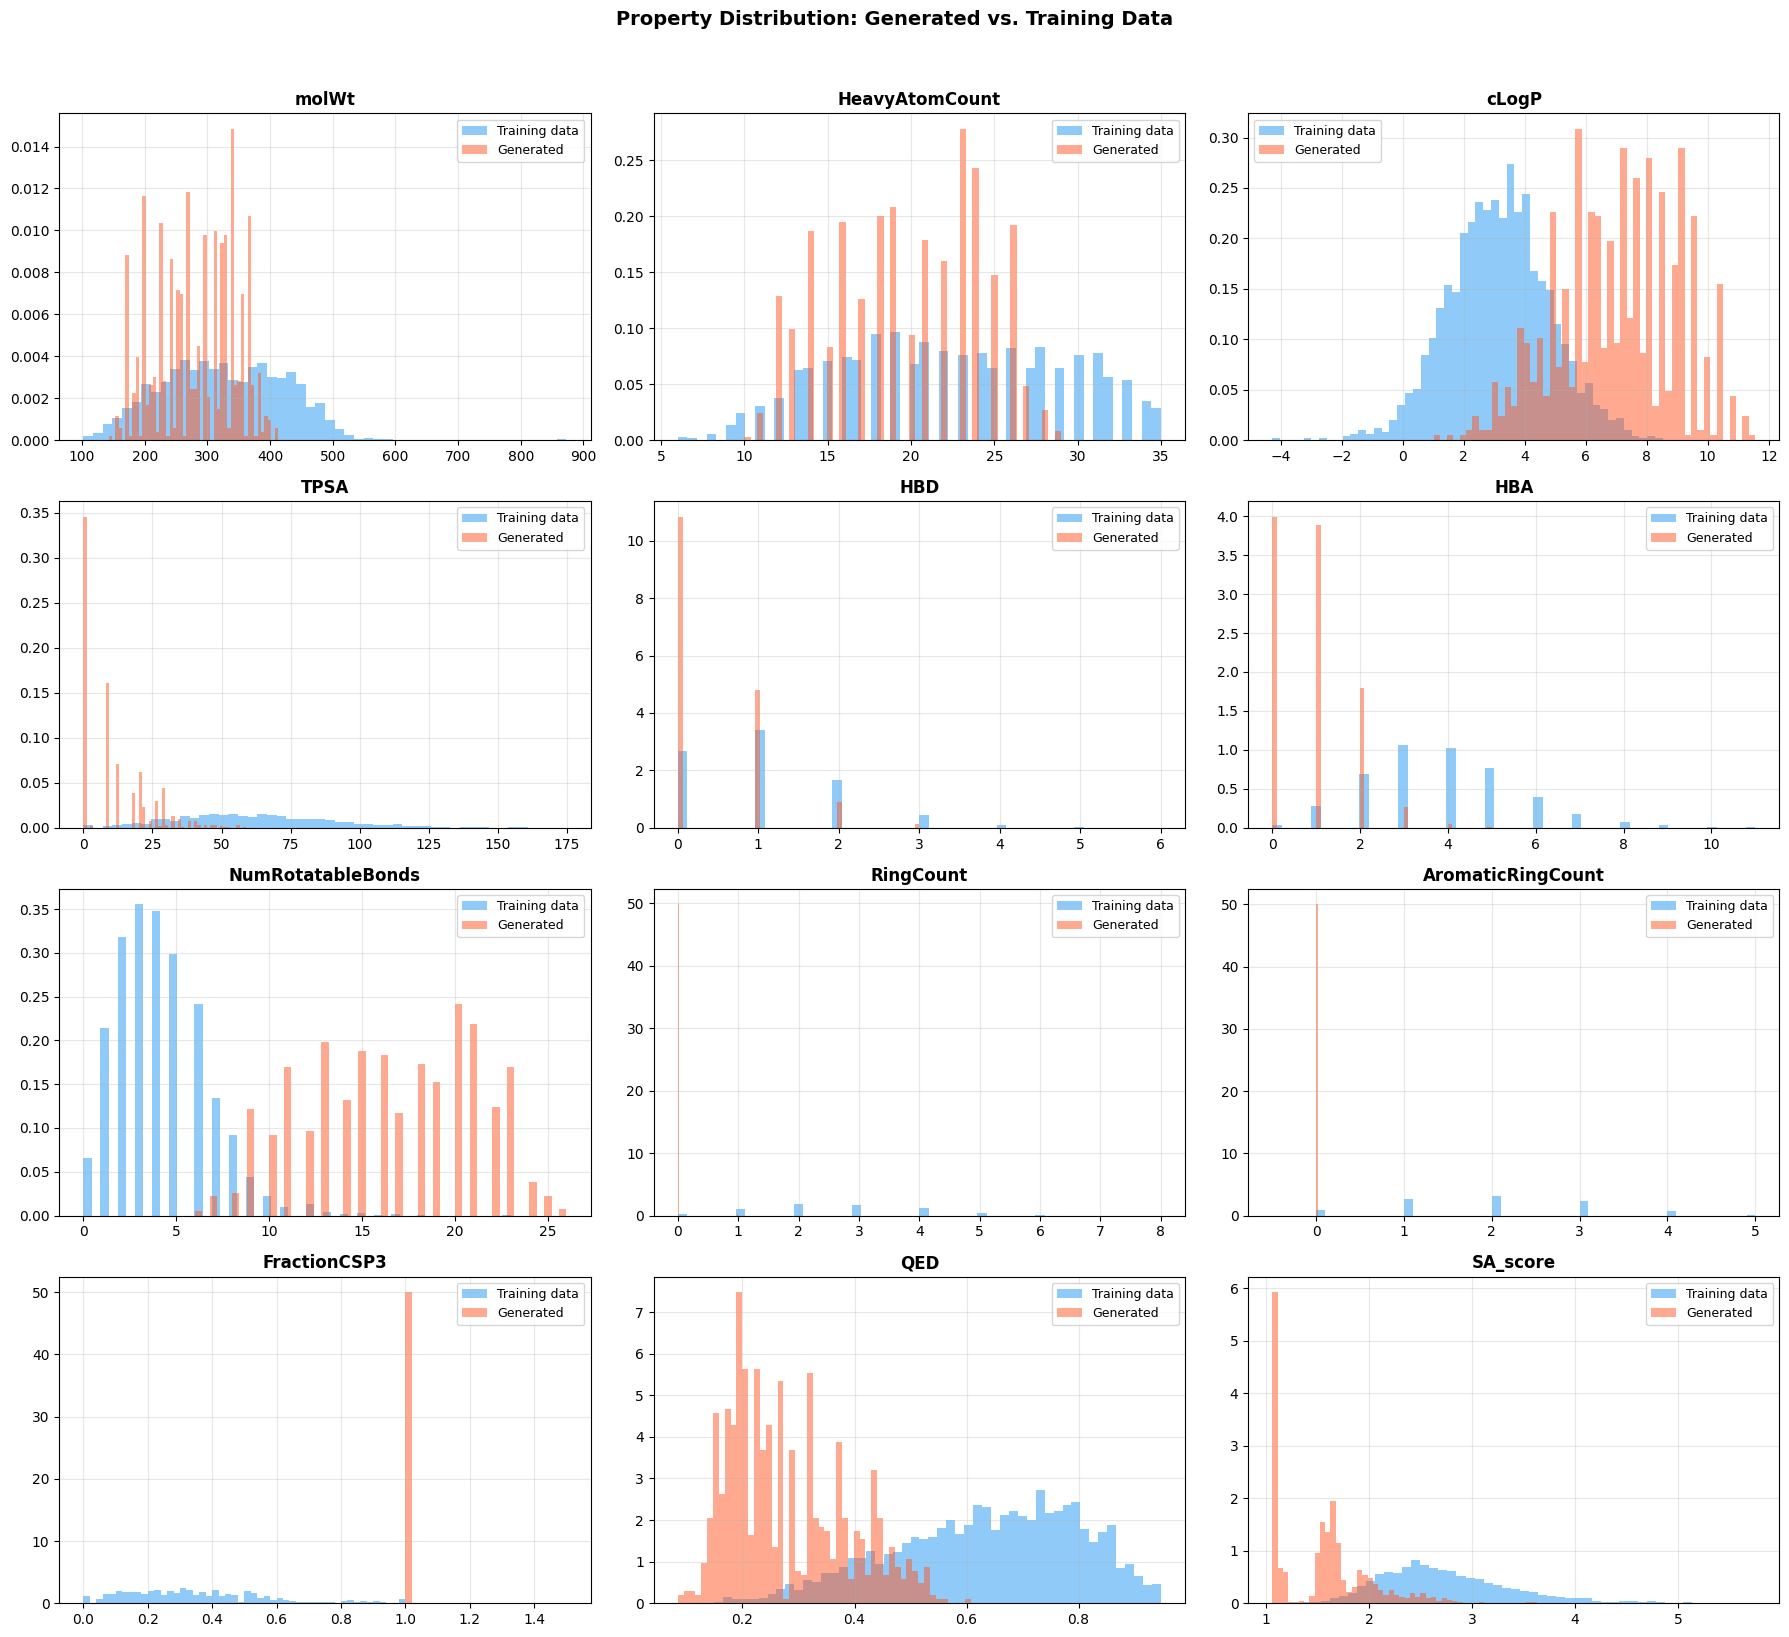

In [23]:
print("Computing properties for training molecules (sample)...")
train_sample = train_dataset[:min(2000, len(train_dataset))]
train_mols = []
for g in train_sample:
    if hasattr(g, 'smiles'):
        mol = Chem.MolFromSmiles(g.smiles)
        if mol:
            train_mols.append(mol)

if train_mols:
    ref_props = evaluator.compute_properties(train_mols)
    evaluator.plot_property_comparison(gen_props, ref_props)
else:
    print("No SMILES found in training data — skipping property comparison.")
    print("Showing generated property distributions only:")
    gen_props.hist(bins=50, figsize=(15, 10))
    plt.suptitle('Generated Molecule Properties', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Latent Space Visualisation (t-SNE)

Encoding: 100%|██████████| 16/16 [00:00<00:00, 16.28it/s]


Running t-SNE on 1986 points...


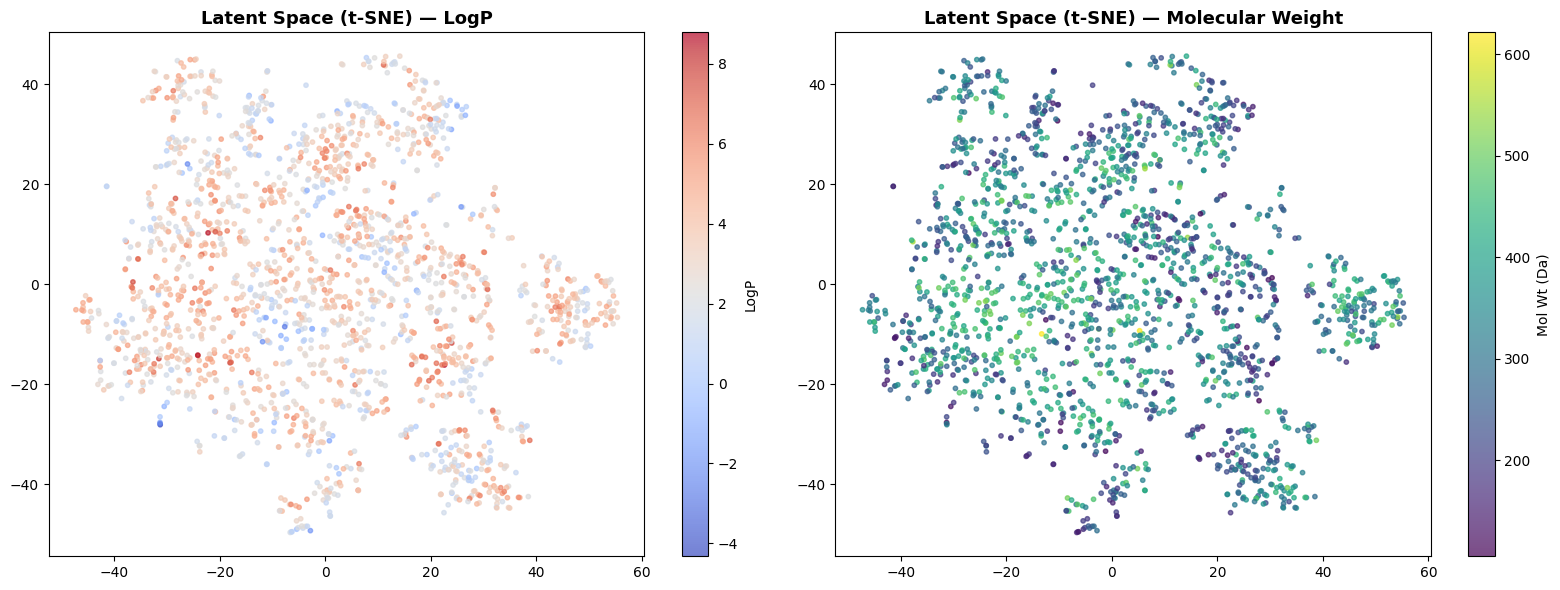

In [24]:
evaluator.visualize_latent_space(
    val_loader,
    config=config,
    max_points=MAX_TSNE_POINTS
)

## 7. Generated Molecule Gallery

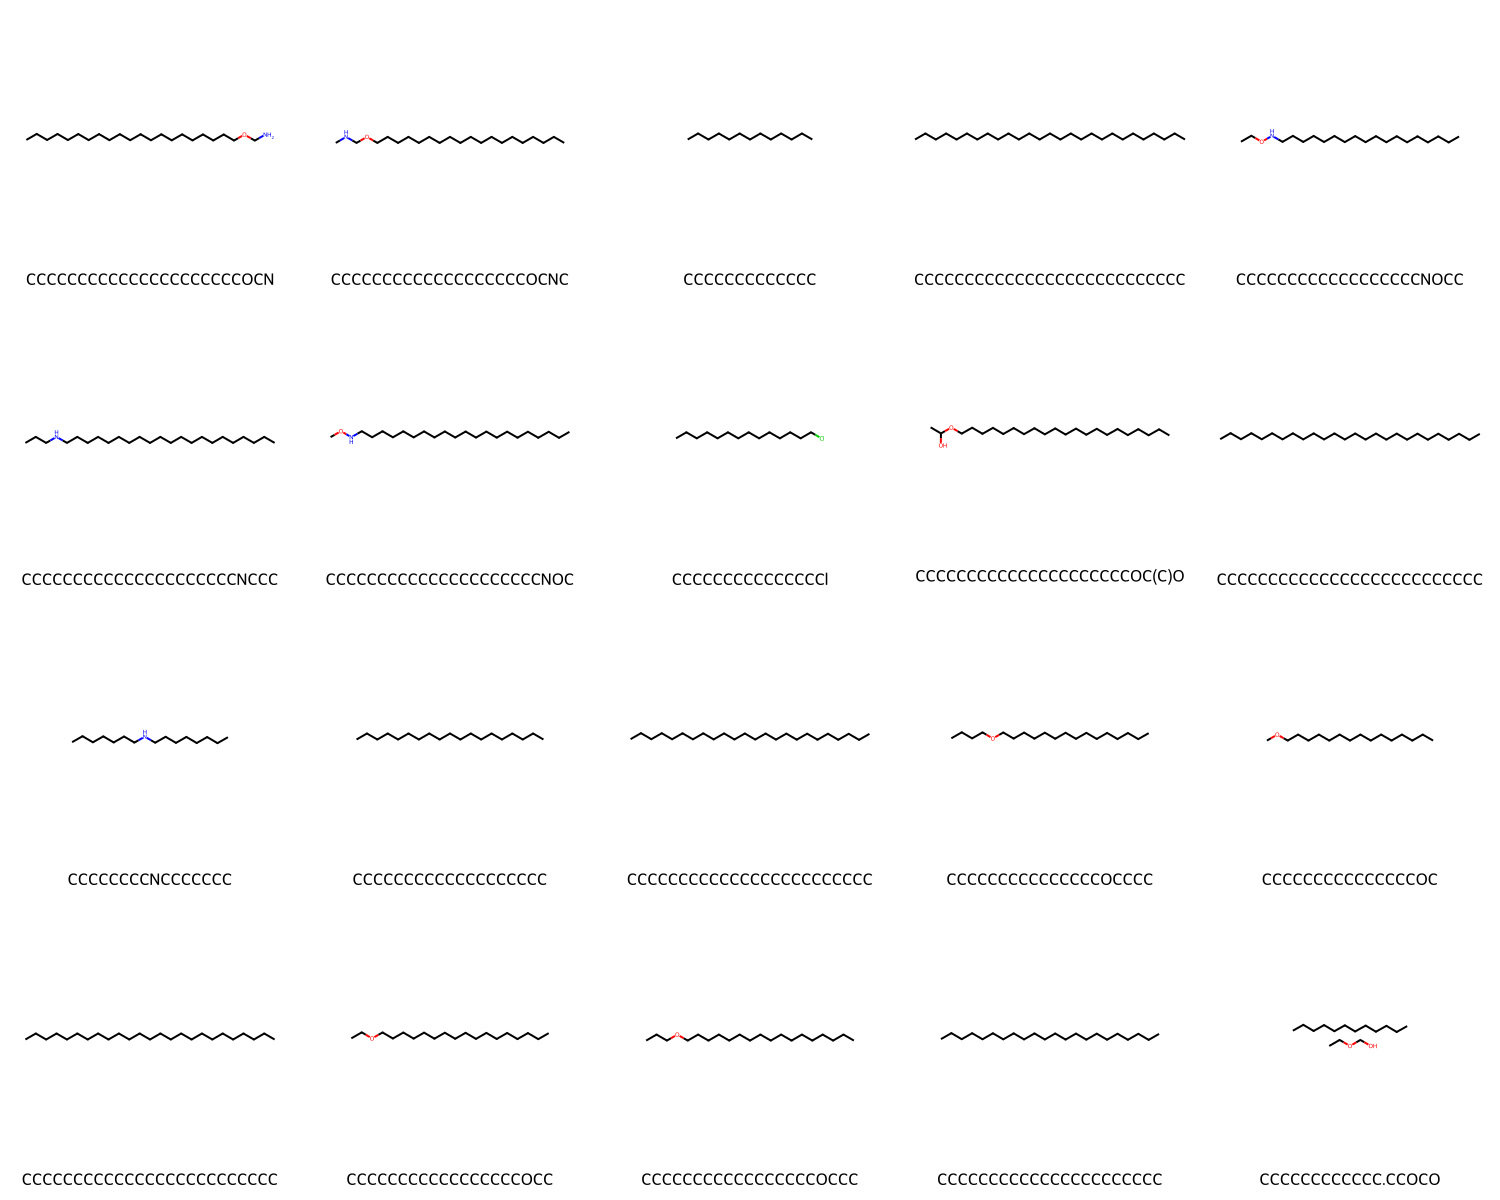

In [25]:
img = evaluator.draw_molecule_gallery(valid_mols, n=20, mols_per_row=5)
display(img)